In [25]:
# FraudShield AI — Intelligent Financial Fraud Detection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
# Dataset path

DATA_PATH = Path("../data/creditcard.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

print("Dataset found:", DATA_PATH)

Dataset found: ..\data\creditcard.csv


In [6]:
# Load fraud transaction dataset

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (116942, 31)


In [8]:
# Preview the dataset

display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [9]:
# Dataset structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116942 entries, 0 to 116941
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    116942 non-null  int64  
 1   V1      116942 non-null  float64
 2   V2      116942 non-null  float64
 3   V3      116942 non-null  float64
 4   V4      116942 non-null  float64
 5   V5      116942 non-null  float64
 6   V6      116942 non-null  float64
 7   V7      116941 non-null  float64
 8   V8      116941 non-null  float64
 9   V9      116941 non-null  float64
 10  V10     116941 non-null  float64
 11  V11     116941 non-null  float64
 12  V12     116941 non-null  float64
 13  V13     116941 non-null  float64
 14  V14     116941 non-null  float64
 15  V15     116941 non-null  float64
 16  V16     116941 non-null  float64
 17  V17     116941 non-null  float64
 18  V18     116941 non-null  float64
 19  V19     116941 non-null  float64
 20  V20     116941 non-null  float64
 21  V21     11

In [10]:
# Numerical statistics

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Time,116942.0,46555.919858,18692.683683,0.000000,35373.000000,48402.000000,61799.000000,74484.000000
V1,116942.0,-0.254372,1.837763,-56.407510,-1.021560,-0.263961,1.155504,1.960497
V2,116942.0,-0.011079,1.633274,-72.715728,-0.586654,0.087372,0.752744,18.902453
V3,116942.0,0.679823,1.296662,-33.680984,0.174900,0.754080,1.376219,4.226108
V4,116942.0,0.155177,1.335851,-5.172595,-0.705556,0.182479,1.014715,16.715537
V5,116942.0,-0.283503,1.333416,-42.147898,-0.904684,-0.316101,0.243386,34.801666
V6,116942.0,0.091362,1.293633,-26.160506,-0.651636,-0.161610,0.482518,22.529298
V7,116941.0,-0.115035,1.193083,-31.764946,-0.602491,-0.067533,0.411126,36.677268
V8,116941.0,0.059857,1.226684,-73.216718,-0.133967,0.077845,0.370001,20.007208
V9,116941.0,-0.072416,1.097922,-9.283925,-0.703675,-0.136354,0.512976,10.392889


In [11]:
# Check missing values

missing = df.isnull().sum()

missing = missing[missing > 0]

if missing.empty:
    print("No missing values found.")
else:
    display(missing.sort_values(ascending=False))

V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

In [12]:
# Check duplicate transactions

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 463


In [13]:
# Target variable

print("Target column: Class")
print("\nUnique values:")
print(df["Class"].unique())

print("\nClass counts:")
print(df["Class"].value_counts())

Target column: Class

Unique values:
[ 0.  1. nan]

Class counts:
Class
0.0    116697
1.0       244
Name: count, dtype: int64


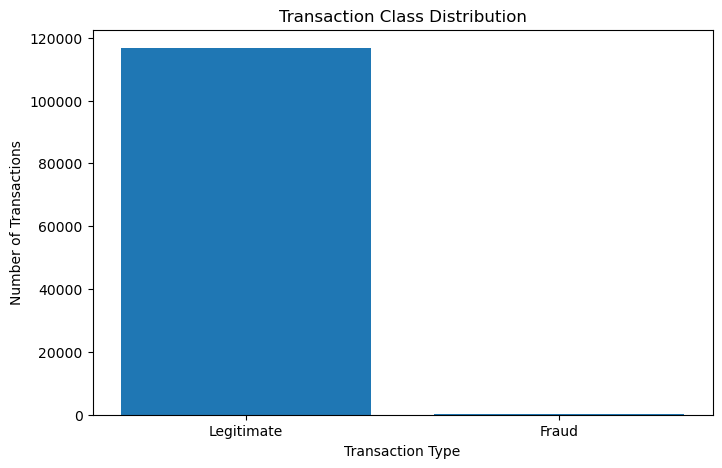

In [14]:
# Fraud vs legitimate transaction distribution

class_counts = df["Class"].value_counts().sort_index()

labels = ["Legitimate", "Fraud"]

plt.figure(figsize=(8, 5))
plt.bar(labels, class_counts.values)

plt.title("Transaction Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [15]:
# Calculate class percentages

class_percentage = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

for class_value, percentage in class_percentage.items():
    label = "Legitimate" if class_value == 0 else "Fraud"
    print(f"{label}: {percentage:.4f}%")

Legitimate: 99.7913%
Fraud: 0.2087%


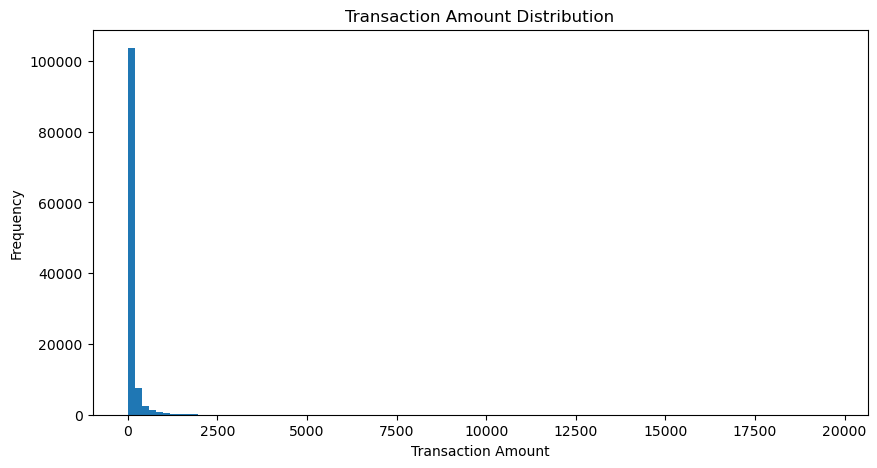

In [16]:
# Transaction amount distribution

plt.figure(figsize=(10, 5))

plt.hist(df["Amount"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

C:\Users\prate\AppData\Local\Temp\ipykernel_20880\1979905017.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


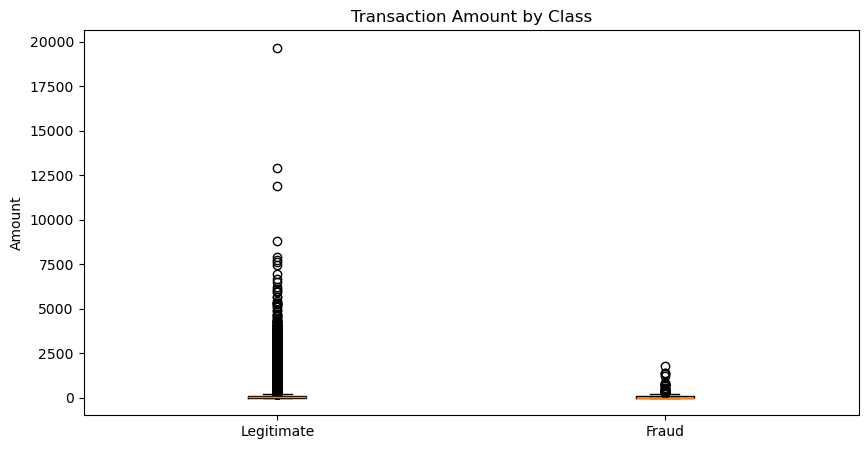

In [17]:
# Compare transaction amounts by class

plt.figure(figsize=(10, 5))

plt.boxplot(
    [
        df.loc[df["Class"] == 0, "Amount"],
        df.loc[df["Class"] == 1, "Amount"]
    ],
    labels=["Legitimate", "Fraud"]
)

plt.title("Transaction Amount by Class")
plt.ylabel("Amount")

plt.show()

In [18]:
# Convert elapsed time into hours

df["Hour"] = (df["Time"] / 3600) % 24

display(df[["Time", "Hour", "Class"]].head())

,Time,Hour,Class
0,0,0.000000,0.0
1,0,0.000000,0.0
2,1,0.000278,0.0
3,1,0.000278,0.0
4,2,0.000556,0.0


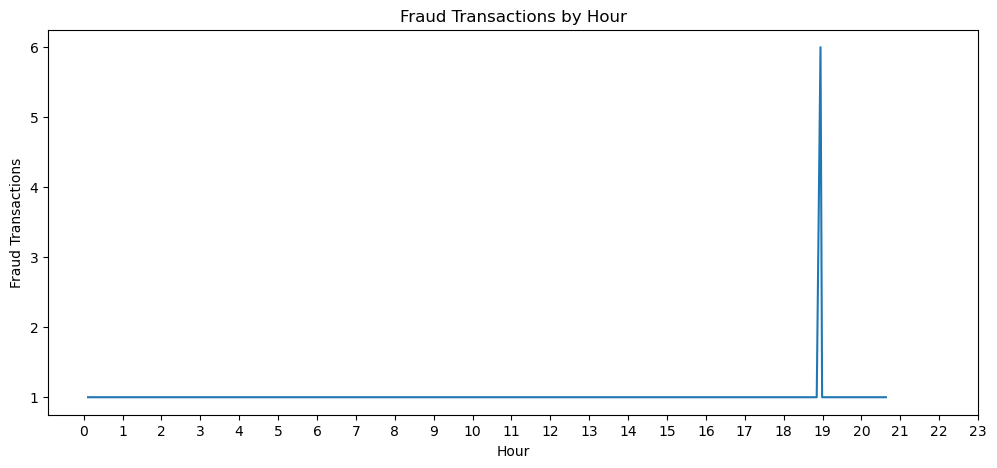

In [19]:
# Fraud transactions by hour

fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(fraud_by_hour.index, fraud_by_hour.values)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Transactions")

plt.xticks(range(0, 24))

plt.show()

In [20]:
# Correlation with fraud target

correlation = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values()
)

display(correlation.to_frame("Correlation with Fraud"))

,Correlation with Fraud
V17,-0.394247
V14,-0.359137
V3,-0.290041
V12,-0.285786
V10,-0.256153
V16,-0.241440
V7,-0.235749
V18,-0.148164
V1,-0.140700
V5,-0.134728


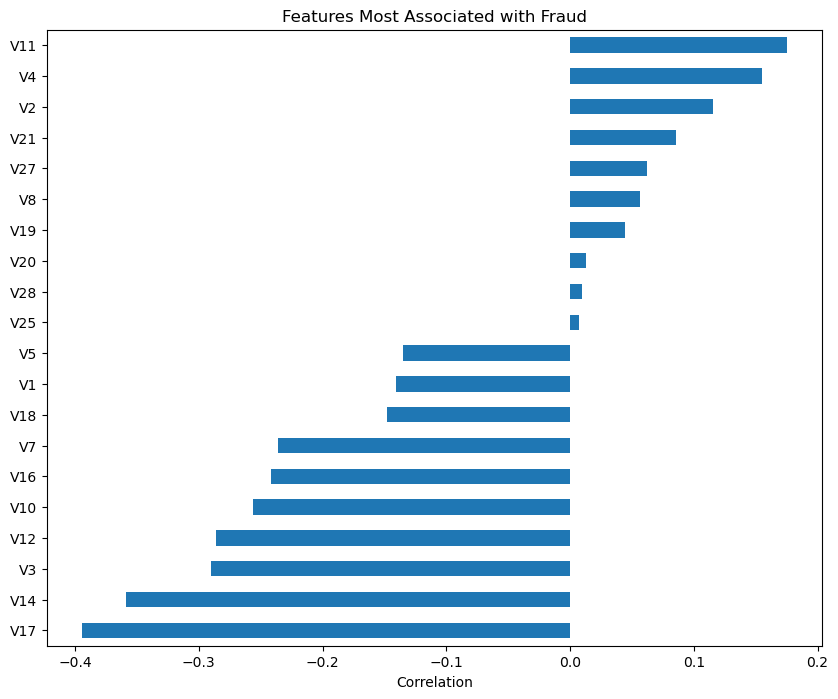

In [21]:
# Visualize strongest correlations with fraud

top_corr = pd.concat([
    correlation.head(10),
    correlation.tail(10)
])

plt.figure(figsize=(10, 8))

top_corr.sort_values().plot(kind="barh")

plt.title("Features Most Associated with Fraud")
plt.xlabel("Correlation")

plt.show()

## Initial Dataset Findings

- The dataset contains approximately 284K transactions.
- Fraud transactions represent a very small minority of the dataset.
- The target variable is `Class`.
- `Class = 0` represents legitimate transactions.
- `Class = 1` represents fraudulent transactions.
- The severe class imbalance makes accuracy alone an unreliable evaluation metric.
- Precision, Recall, F1 Score and ROC-AUC will therefore be important during model evaluation.
- The dataset contains anonymized PCA-transformed features (`V1`–`V28`), along with `Time` and `Amount`.

In [29]:
# Separate features and target safely

TARGET = "Class"

# Remove rows where target is missing
df = df.dropna(subset=[TARGET]).copy()

# Make target numeric
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

# Remove any rows that became invalid
df = df.dropna(subset=[TARGET]).copy()

# Keep only valid fraud labels
df = df[df[TARGET].isin([0, 1])].copy()

# Convert target to integer
df[TARGET] = df[TARGET].astype(int)

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing target values:", y.isna().sum())
print("\nFeature columns:", X.shape[1])

Features shape: (116941, 31)
Target shape: (116941,)

Target distribution:
Class
0    116697
1       244
Name: count, dtype: int64

Missing target values: 0

Feature columns: 31


In [31]:
X = df.drop(columns=["Class"])

In [32]:
print("All columns:")
print(df.columns.tolist())

print("\nTarget column exists:", TARGET in df.columns)
print("X contains target:", TARGET in X.columns)

All columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Hour']

Target column exists: True
X contains target: False


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (93552, 31)
Testing set: (23389, 31)

Training target distribution:
Class
0    93357
1      195
Name: count, dtype: int64

Testing target distribution:
Class
0    23340
1       49
Name: count, dtype: int64


In [34]:
print("Current dataset shape:", df.shape)
print("Original target counts:")
print(df["Class"].value_counts())

Current dataset shape: (116941, 32)
Original target counts:
Class
0    116697
1       244
Name: count, dtype: int64


In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_features = X_train.columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## Baseline Models

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

print("Models ready:")
for name in models:
    print("→", name)

Models ready:
→ Logistic Regression
→ KNN
→ Naive Bayes
→ Random Forest
→ Gradient Boosting


In [42]:
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} training complete.")

print("\nAll models trained successfully.")


Training Logistic Regression...
Logistic Regression training complete.

Training KNN...
KNN training complete.

Training Naive Bayes...
Naive Bayes training complete.

Training Random Forest...
Random Forest training complete.

Training Gradient Boosting...
Gradient Boosting training complete.

All models trained successfully.


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_data, y_data):

    predictions = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_data)[:, 1]
    else:
        probabilities = None

    results = {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_data,
            predictions,
            zero_division=0
        )
    }

    if probabilities is not None:
        results["ROC-AUC"] = roc_auc_score(
            y_data,
            probabilities
        )
    else:
        results["ROC-AUC"] = np.nan

    return results

In [45]:
results = []

for name, model in trained_models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

baseline_results = pd.DataFrame(results)

baseline_results = baseline_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

baseline_results = baseline_results.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(baseline_results)

Evaluating Logistic Regression...
Evaluating KNN...
Evaluating Naive Bayes...
Evaluating Random Forest...
Evaluating Gradient Boosting...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.999487,0.951220,0.795918,0.866667,0.915169
1,KNN,0.999316,0.866667,0.795918,0.829787,0.907974
2,Logistic Regression,0.998546,0.741935,0.469388,0.575000,0.923049
3,Gradient Boosting,0.998461,0.696970,0.469388,0.560976,0.632098
4,Naive Bayes,0.978109,0.072089,0.795918,0.132203,0.922896


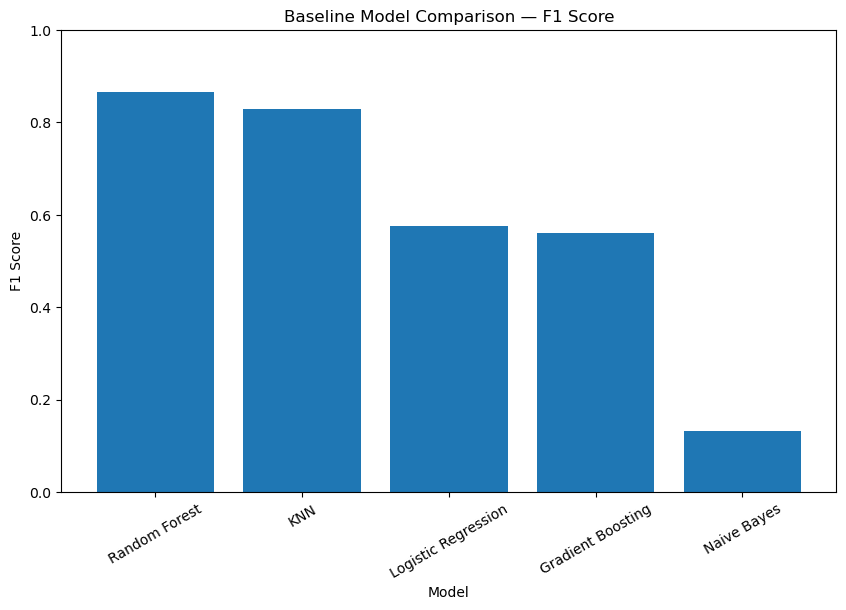

In [46]:
plt.figure(figsize=(10, 6))

plt.bar(
    baseline_results["Model"],
    baseline_results["F1 Score"]
)

plt.title("Baseline Model Comparison — F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

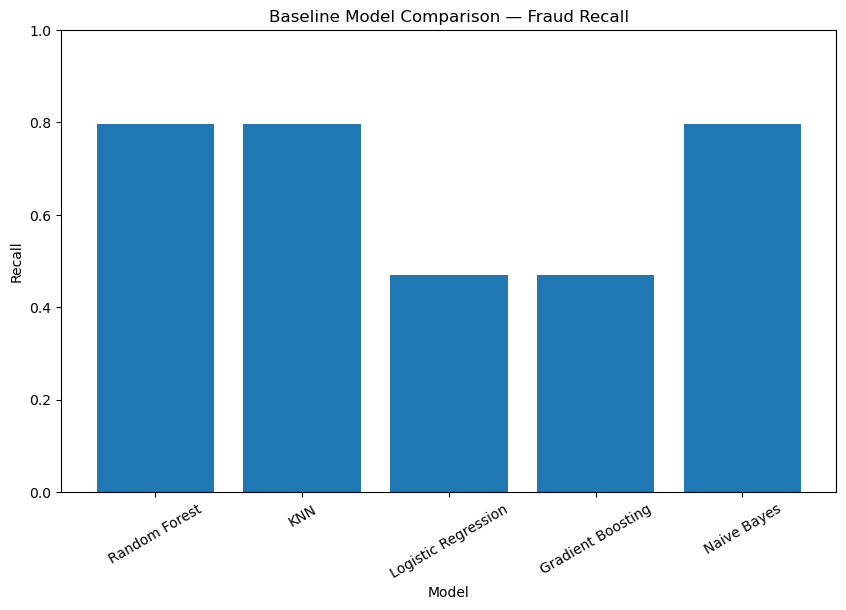

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    baseline_results["Model"],
    baseline_results["Recall"]
)

plt.title("Baseline Model Comparison — Fraud Recall")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

In [49]:
from sklearn.metrics import classification_report
best_baseline_name = baseline_results.iloc[0]["Model"]

best_baseline_model = trained_models[
    best_baseline_name
]

print("Best baseline model:", best_baseline_name)

predictions = best_baseline_model.predict(X_test)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Best baseline model: Random Forest

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     23340
       Fraud       0.95      0.80      0.87        49

    accuracy                           1.00     23389
   macro avg       0.98      0.90      0.93     23389
weighted avg       1.00      1.00      1.00     23389



<Figure size 700x600 with 0 Axes>

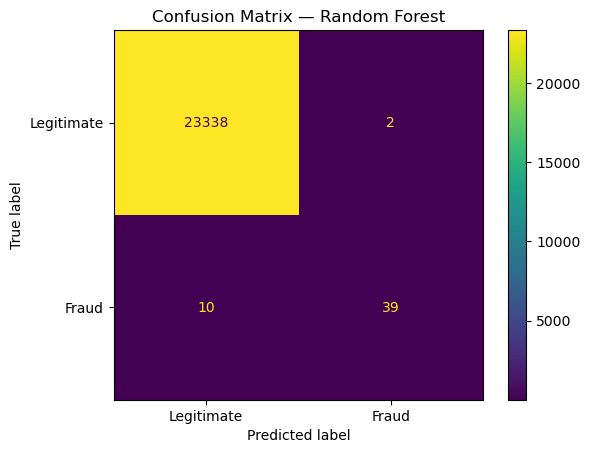

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format="d"
)

plt.title(f"Confusion Matrix — {best_baseline_name}")

plt.show()

## Baseline Model Findings

The initial models were trained on the original highly imbalanced dataset without applying SMOTE or class weighting.

Model evaluation focused on Accuracy, Precision, Recall, F1 Score and ROC-AUC.

Accuracy alone is not sufficient for evaluating this fraud detection problem because legitimate transactions heavily outnumber fraudulent transactions.

Particular attention is given to:

- Fraud Recall
- Precision
- F1 Score
- ROC-AUC
- False Negatives

The baseline results will be compared against imbalance-handling approaches in the next phase.

In [51]:
# FraudShield AI — Class Imbalance Analysis

print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(4)
)

Training class distribution:
Class
0    93357
1      195
Name: count, dtype: int64

Training class percentages:
Class
0    99.7916
1     0.2084
Name: proportion, dtype: float64


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

weighted_models = {
    "Logistic Regression (Balanced)": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),

    "Random Forest (Balanced)": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

weighted_trained = {}

for name, model in weighted_models.items():

    print(f"Training {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    weighted_trained[name] = pipeline

    print("Complete.")

print("\nAll class-weighted models trained.")

Training Logistic Regression (Balanced)...
Complete.
Training Random Forest (Balanced)...
Complete.

All class-weighted models trained.


In [53]:
weighted_results = []

for name, model in weighted_trained.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name
    weighted_results.append(metrics)

weighted_results = pd.DataFrame(weighted_results)

weighted_results = weighted_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

display(weighted_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Balanced),0.981786,0.085714,0.795918,0.154762,0.937279
1,Random Forest (Balanced),0.999487,0.974359,0.775510,0.863636,0.915815


In [55]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("SMOTE pipeline components loaded.")

SMOTE pipeline components loaded.


In [56]:
smote_lr = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(
        random_state=42,
        sampling_strategy="auto"
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print("Training SMOTE + Logistic Regression...")

smote_lr.fit(X_train, y_train)

print("Training complete.")

Training SMOTE + Logistic Regression...
Training complete.


In [57]:
smote_rf = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(
        random_state=42,
        sampling_strategy="auto"
    )),
    ("model", RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training SMOTE + Random Forest...")

smote_rf.fit(X_train, y_train)

print("Training complete.")

Training SMOTE + Random Forest...
Training complete.


In [58]:
smote_models = {
    "SMOTE + Logistic Regression": smote_lr,
    "SMOTE + Random Forest": smote_rf
}

smote_results = []

for name, model in smote_models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["Model"] = name
    smote_results.append(metrics)

smote_results = pd.DataFrame(smote_results)

smote_results = smote_results[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
]

display(smote_results)

Evaluating SMOTE + Logistic Regression...
Evaluating SMOTE + Random Forest...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SMOTE + Logistic Regression,0.982086,0.087054,0.795918,0.156942,0.934924
1,SMOTE + Random Forest,0.999444,0.928571,0.795918,0.857143,0.976569


In [59]:
# Combine all model results

all_results = pd.concat(
    [
        baseline_results,
        weighted_results,
        smote_results
    ],
    ignore_index=True
)

all_results = all_results.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(all_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.999487,0.951220,0.795918,0.866667,0.915169
1,Random Forest (Balanced),0.999487,0.974359,0.775510,0.863636,0.915815
2,SMOTE + Random Forest,0.999444,0.928571,0.795918,0.857143,0.976569
3,KNN,0.999316,0.866667,0.795918,0.829787,0.907974
4,Logistic Regression,0.998546,0.741935,0.469388,0.575000,0.923049
5,Gradient Boosting,0.998461,0.696970,0.469388,0.560976,0.632098
6,SMOTE + Logistic Regression,0.982086,0.087054,0.795918,0.156942,0.934924
7,Logistic Regression (Balanced),0.981786,0.085714,0.795918,0.154762,0.937279
8,Naive Bayes,0.978109,0.072089,0.795918,0.132203,0.922896


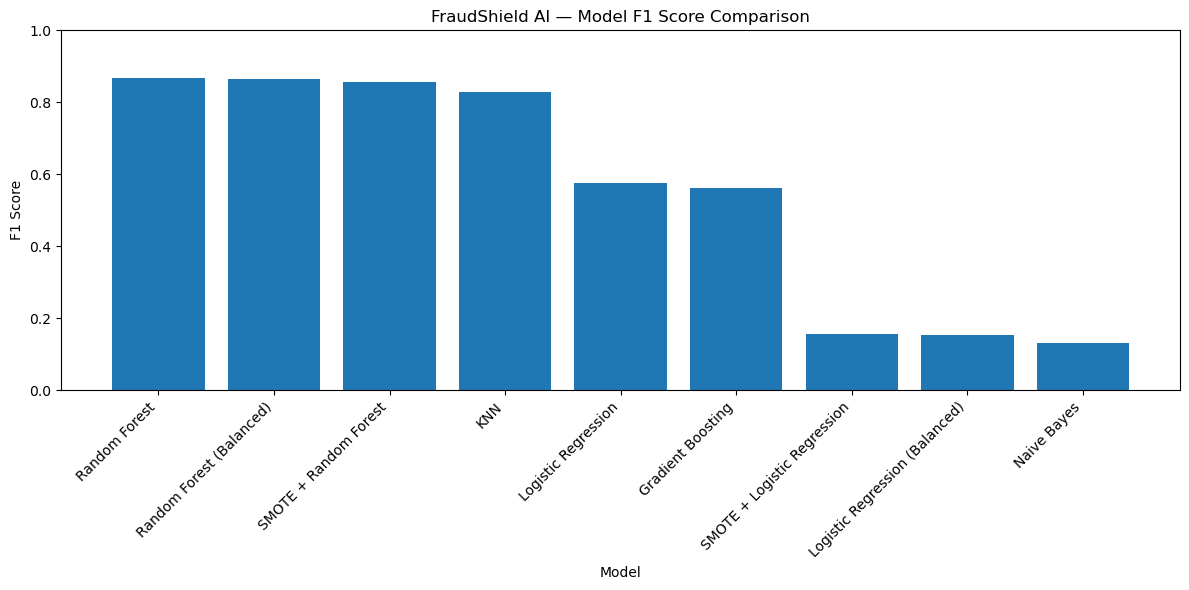

In [60]:
plt.figure(figsize=(12, 6))

plt.bar(
    all_results["Model"],
    all_results["F1 Score"]
)

plt.title("FraudShield AI — Model F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

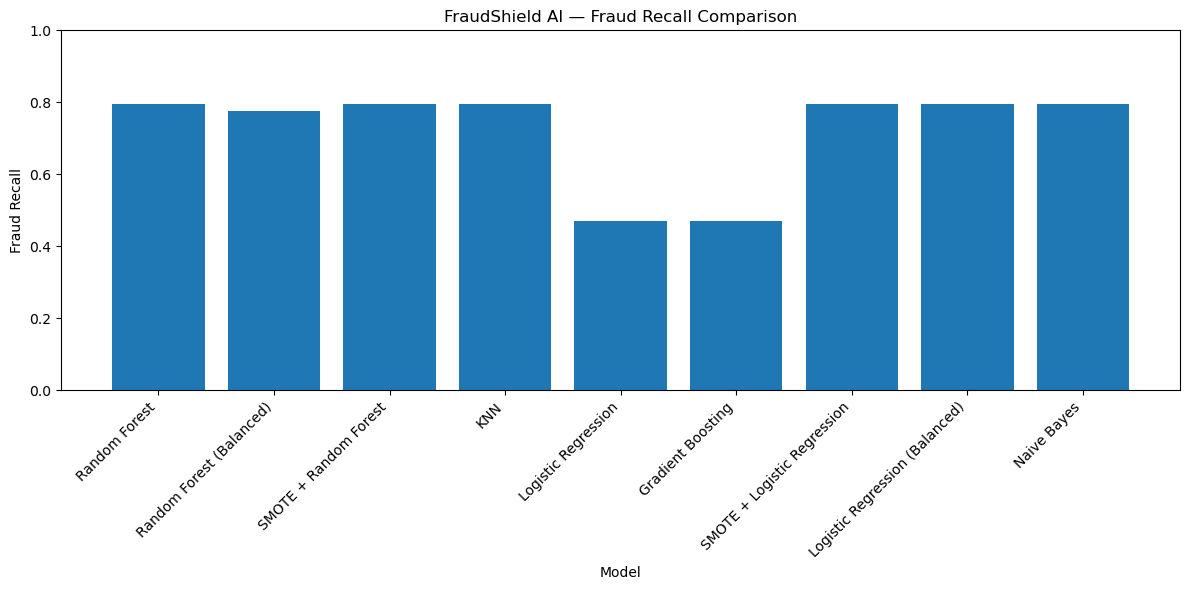

In [61]:
plt.figure(figsize=(12, 6))

plt.bar(
    all_results["Model"],
    all_results["Recall"]
)

plt.title("FraudShield AI — Fraud Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Fraud Recall")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [62]:
best_model_name = all_results.iloc[0]["Model"]

print("Current best model:", best_model_name)

display(
    all_results.iloc[[0]]
)

Current best model: Random Forest


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.999487,0.95122,0.795918,0.866667,0.915169


In [63]:
all_trained_models = {}

all_trained_models.update(trained_models)
all_trained_models.update(weighted_trained)
all_trained_models.update(smote_models)

best_model = all_trained_models[best_model_name]

print("Selected candidate:", best_model_name)

Selected candidate: Random Forest


In [64]:
best_predictions = best_model.predict(X_test)

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     23340
       Fraud       0.95      0.80      0.87        49

    accuracy                           1.00     23389
   macro avg       0.98      0.90      0.93     23389
weighted avg       1.00      1.00      1.00     23389



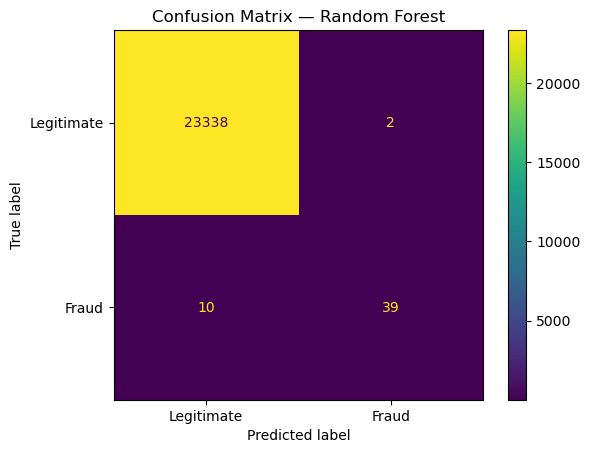

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format="d"
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## Final Model Selection

FraudShield AI evaluates models using multiple metrics rather than relying solely on accuracy.

Because fraudulent transactions represent a very small minority of the dataset, particular importance is given to:

- Precision
- Recall
- F1 Score
- ROC-AUC
- False Negatives

Baseline models were compared against class-weighted and SMOTE-based approaches.

The final model will be selected based on the actual evaluation results and the balance between detecting fraudulent transactions and minimizing false fraud alerts.

In [66]:
display(all_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.999487,0.951220,0.795918,0.866667,0.915169
1,Random Forest (Balanced),0.999487,0.974359,0.775510,0.863636,0.915815
2,SMOTE + Random Forest,0.999444,0.928571,0.795918,0.857143,0.976569
3,KNN,0.999316,0.866667,0.795918,0.829787,0.907974
4,Logistic Regression,0.998546,0.741935,0.469388,0.575000,0.923049
5,Gradient Boosting,0.998461,0.696970,0.469388,0.560976,0.632098
6,SMOTE + Logistic Regression,0.982086,0.087054,0.795918,0.156942,0.934924
7,Logistic Regression (Balanced),0.981786,0.085714,0.795918,0.154762,0.937279
8,Naive Bayes,0.978109,0.072089,0.795918,0.132203,0.922896


In [67]:
# FraudShield AI — Final Model Selection

FINAL_MODEL_NAME = "Random Forest"

final_model = trained_models[FINAL_MODEL_NAME]

final_metrics = all_results[
    all_results["Model"] == FINAL_MODEL_NAME
].iloc[0]

print("=" * 60)
print("FraudShield AI — Final Model")
print("=" * 60)

print("Model:", FINAL_MODEL_NAME)
print(f"Accuracy:  {final_metrics['Accuracy']:.4%}")
print(f"Precision: {final_metrics['Precision']:.4%}")
print(f"Recall:    {final_metrics['Recall']:.4%}")
print(f"F1 Score:  {final_metrics['F1 Score']:.4%}")
print(f"ROC-AUC:   {final_metrics['ROC-AUC']:.4%}")

FraudShield AI — Final Model
Model: Random Forest
Accuracy:  99.9487%
Precision: 95.1220%
Recall:    79.5918%
F1 Score:  86.6667%
ROC-AUC:   91.5169%


In [68]:
# Generate final predictions

final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Test samples:", len(final_predictions))

Predictions generated successfully.
Test samples: 23389


In [69]:
from sklearn.metrics import classification_report

print("FraudShield AI — Final Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

FraudShield AI — Final Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     23340
       Fraud       0.95      0.80      0.87        49

    accuracy                           1.00     23389
   macro avg       0.98      0.90      0.93     23389
weighted avg       1.00      1.00      1.00     23389



Confusion Matrix:
[[23338     2]
 [   10    39]]


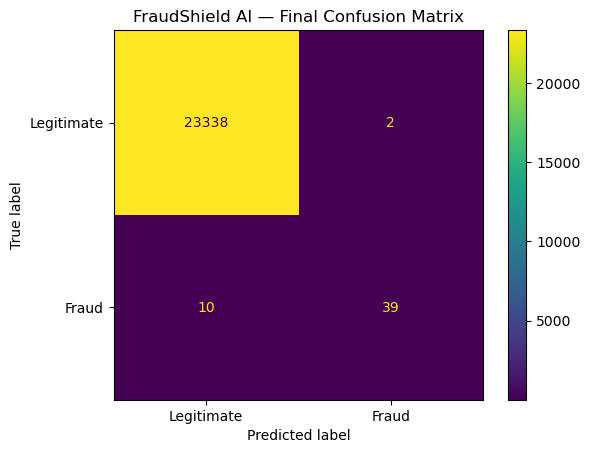

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    final_predictions
)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot(values_format="d")

plt.title("FraudShield AI — Final Confusion Matrix")
plt.show()

In [71]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "fraud_model.pkl"

joblib.dump(
    final_model,
    MODEL_PATH
)

print("Model saved successfully:")
print(MODEL_PATH)

Model saved successfully:
..\models\fraud_model.pkl


In [72]:
# Save model metadata for the Streamlit application

metadata = {
    "project": "FraudShield AI",
    "model": FINAL_MODEL_NAME,
    "features": X.columns.tolist(),
    "target": "Class",
    "target_mapping": {
        0: "Legitimate",
        1: "Fraud"
    },
    "metrics": {
        "accuracy": float(final_metrics["Accuracy"]),
        "precision": float(final_metrics["Precision"]),
        "recall": float(final_metrics["Recall"]),
        "f1_score": float(final_metrics["F1 Score"]),
        "roc_auc": float(final_metrics["ROC-AUC"])
    },
    "dataset_rows": int(len(df)),
    "feature_count": int(X.shape[1])
}

METADATA_PATH = MODEL_DIR / "model_metadata.pkl"

joblib.dump(
    metadata,
    METADATA_PATH
)

print("Metadata saved successfully:")
print(METADATA_PATH)

Metadata saved successfully:
..\models\model_metadata.pkl


In [73]:
# Reload the saved model to verify serialization

loaded_model = joblib.load(MODEL_PATH)

test_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print("Model reload successful.")
print("Sample predictions:", test_prediction)

Model reload successful.
Sample predictions: [0 0 0 0 0]


In [74]:
print("=" * 65)
print("🛡️ FraudShield AI — Training Complete")
print("=" * 65)

print(f"Dataset size:       {len(df):,} rows")
print(f"Input features:     {X.shape[1]}")
print(f"Best model:         {FINAL_MODEL_NAME}")

print(f"Accuracy:           {final_metrics['Accuracy']:.2%}")
print(f"Precision:          {final_metrics['Precision']:.2%}")
print(f"Recall:             {final_metrics['Recall']:.2%}")
print(f"F1 Score:           {final_metrics['F1 Score']:.2%}")
print(f"ROC-AUC:            {final_metrics['ROC-AUC']:.2%}")

print("\nSaved files:")
print("→ models/fraud_model.pkl")
print("→ models/model_metadata.pkl")

🛡️ FraudShield AI — Training Complete
Dataset size:       116,941 rows
Input features:     31
Best model:         Random Forest
Accuracy:           99.95%
Precision:          95.12%
Recall:             79.59%
F1 Score:           86.67%
ROC-AUC:            91.52%

Saved files:
→ models/fraud_model.pkl
→ models/model_metadata.pkl


In [76]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)